In [5]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import faiss
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


# Load sentence embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')


In [5]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import faiss
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


# Load sentence embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')


In [6]:
# Example texts
texts = [
    "The cat sits on the mat.",
    "A dog is playing with a ball.",
    "I love programming in Python.",
    "Machine learning is fascinating.",
    "The weather today is sunny and bright.",
    "Artificial Intelligence is the future.",
    "Let's grab some coffee later.",
    "Deep learning is a subset of machine learning."
]

# Encode texts to embeddings
embeddings = model.encode(texts)

# Calculate cosine similarity matrix
cos_sim = util.cos_sim(embeddings, embeddings)
print("Cosine similarity matrix:\n", cos_sim)


Cosine similarity matrix:
 tensor([[ 1.0000,  0.1752,  0.0271, -0.0448, -0.0380, -0.0262,  0.0510, -0.1061],
        [ 0.1752,  1.0000,  0.1162,  0.0742,  0.0333,  0.0967,  0.0244,  0.0473],
        [ 0.0271,  0.1162,  1.0000,  0.3546,  0.0266,  0.3296,  0.0785,  0.2375],
        [-0.0448,  0.0742,  0.3546,  1.0000,  0.0011,  0.5590,  0.1170,  0.5831],
        [-0.0380,  0.0333,  0.0266,  0.0011,  1.0000,  0.0185,  0.1752, -0.0124],
        [-0.0262,  0.0967,  0.3296,  0.5590,  0.0185,  1.0000,  0.1805,  0.5167],
        [ 0.0510,  0.0244,  0.0785,  0.1170,  0.1752,  0.1805,  1.0000,  0.0572],
        [-0.1061,  0.0473,  0.2375,  0.5831, -0.0124,  0.5167,  0.0572,  1.0000]])


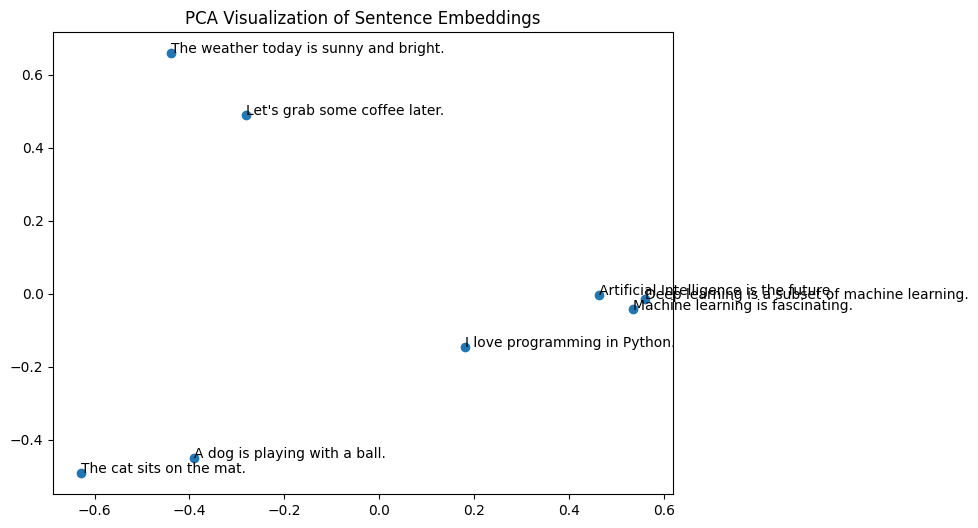

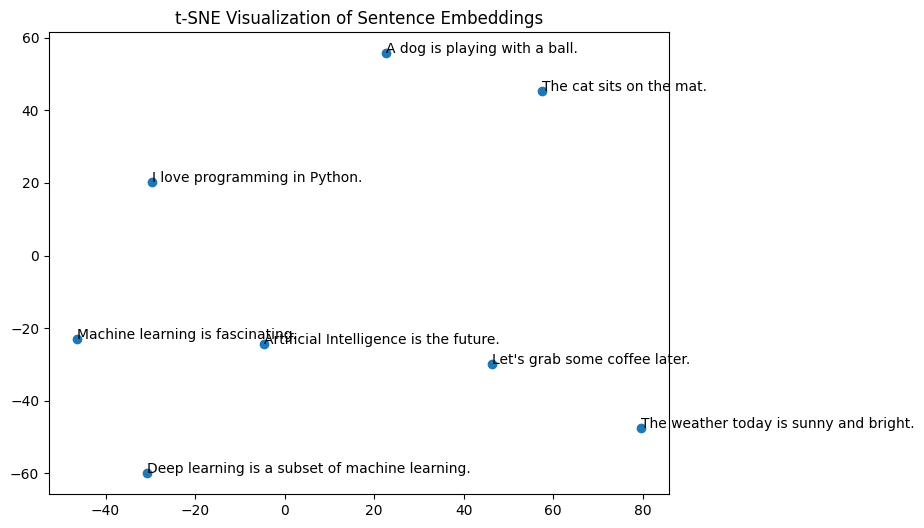

In [7]:
# PCA visualization
pca = PCA(n_components=2)
reduced_pca = pca.fit_transform(embeddings)
plt.figure(figsize=(8,6))
plt.scatter(reduced_pca[:,0], reduced_pca[:,1])
for i, txt in enumerate(texts):
    plt.annotate(txt, (reduced_pca[i,0], reduced_pca[i,1]))
plt.title('PCA Visualization of Sentence Embeddings')
plt.show()

# t-SNE visualization
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
reduced_tsne = tsne.fit_transform(embeddings)
plt.figure(figsize=(8,6))
plt.scatter(reduced_tsne[:,0], reduced_tsne[:,1])
for i, txt in enumerate(texts):
    plt.annotate(txt, (reduced_tsne[i,0], reduced_tsne[i,1]))
plt.title('t-SNE Visualization of Sentence Embeddings')
plt.show()


In [8]:
# Normalize embeddings for FAISS
normalized_embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
dimension = normalized_embeddings.shape[1]

# Create FAISS index
index = faiss.IndexFlatIP(dimension)
index.add(normalized_embeddings)

# Query examples
queries = [
    "What is machine learning?",
    "Tell me about artificial intelligence.",
    "How's the weather today?",
]

query_embeddings = model.encode(queries)
query_embeddings = query_embeddings / np.linalg.norm(query_embeddings, axis=1, keepdims=True)

# Search top 3 matches
top_k = 3
for i, query_embedding in enumerate(query_embeddings):
    distances, indices = index.search(np.array([query_embedding]), top_k)
    print(f"\nQuery: {queries[i]}")
    print("Top matches:")
    for idx in indices[0]:
        print(f"- {texts[idx]}")



Query: What is machine learning?
Top matches:
- Deep learning is a subset of machine learning.
- Machine learning is fascinating.
- Artificial Intelligence is the future.

Query: Tell me about artificial intelligence.
Top matches:
- Artificial Intelligence is the future.
- Machine learning is fascinating.
- Deep learning is a subset of machine learning.

Query: How's the weather today?
Top matches:
- The weather today is sunny and bright.
- Let's grab some coffee later.
- I love programming in Python.
